# Traffic Patterns Forecasting — Time Series Forecasting

**Project:** Traffic Patterns Forecasting with Time Series Models  
**Dataset:** PEMS-BAY traffic-speed benchmark  
**Forecast horizon:** Next 1 hour (12 × 5-minute steps)  
**Approach:** EDA → feature engineering → chronological split → Naive baseline → Random Forest → LSTM → evaluation → future forecast

> The notebook downloads the public PEMS-BAY CSV automatically. PEMS-BAY contains 325 traffic sensors sampled every 5 minutes and is widely used for traffic forecasting. The dataset is available through Zenodo and newer processed versions are also available through Hugging Face. 


In [1]:
# 1. Install/import dependencies
# Run this cell if packages are missing:
# %pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow requests

import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

DATA_DIR = Path("traffic_data")
DATA_DIR.mkdir(exist_ok=True)

print("Environment ready.")


Environment ready.


## 2. Download the latest available public benchmark data

This notebook uses the public PEMS-BAY benchmark archive. The commonly distributed CSV contains traffic measurements from 325 sensors at 5-minute intervals.

The dataset itself is historical rather than live. Therefore, “latest data” here means the latest publicly available version of the selected benchmark/archive, not real-time traffic in 2026.


In [2]:
# Download PEMS-BAY from the public Zenodo archive if it is not already present.
import requests

csv_path = DATA_DIR / "PEMS-BAY.csv"
url = "https://zenodo.org/records/5146275/files/PEMS-BAY.csv?download=1"

if not csv_path.exists():
    print("Downloading PEMS-BAY.csv ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    csv_path.write_bytes(r.content)
    print(f"Downloaded {csv_path.stat().st_size / 1024**2:.1f} MB")
else:
    print("Dataset already exists:", csv_path)

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
display(df.head())


Downloaded 81.7 MB
Shape: (52116, 326)


,Unnamed: 0,400001,400017,400030,400040,400045,400052,400057,400059,400065,400069,400073,400084,400085,400088,400096,400097,400100,400104,400109,400122,400147,400148,400149,400158,400160,400168,400172,400174,400178,400185,400201,400206,400209,400213,400221,400222,400227,400236,400238,400240,400246,400253,400257,400258,400268,400274,400278,400280,400292,...,407185,407186,407187,407190,407191,407194,407200,407202,407204,407206,407207,407321,407323,407325,407328,407331,407332,407335,407336,407337,407339,407341,407342,407344,407348,407352,407359,407360,407361,407364,407367,407370,407372,407373,407374,407710,407711,408907,408911,409524,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
0,2017-01-01 00:00:00,71.4,67.8,70.5,67.4,68.8,66.6,66.8,68.0,66.8,69.0,68.2,67.7,67.7,68.7,67.5,68.4,68.0,68.1,68.8,68.2,67.7,67.4,68.7,66.8,68.5,69.0,68.8,68.4,66.5,67.6,66.8,69.3,69.3,69.5,67.9,67.7,71.6,67.9,68.9,69.6,68.3,68.2,67.1,66.6,66.7,67.7,66.5,69.3,67.9,...,68.2,68.0,68.1,68.5,67.8,67.8,68.6,67.1,67.9,67.1,68.8,68.2,68.0,67.6,66.8,67.7,65.0,68.4,67.1,67.9,68.5,66.6,67.2,68.8,68.2,68.8,65.0,68.4,68.4,67.7,67.9,68.8,67.2,67.3,68.5,63.8,69.0,68.8,68.6,67.2,68.8,67.9,68.8,68.0,69.2,68.9,70.4,68.8,71.1,68.0
1,2017-01-01 00:05:00,71.6,67.5,70.6,67.5,68.7,66.6,66.8,67.8,66.5,68.2,68.0,67.4,67.5,69.2,67.7,68.1,67.8,67.9,68.4,68.1,67.7,67.2,68.8,66.9,68.4,68.8,68.4,68.7,66.7,67.2,67.1,69.0,69.4,69.2,67.3,67.5,71.2,67.2,68.4,69.1,67.9,68.1,66.6,66.1,66.6,68.0,66.8,69.2,67.5,...,66.9,68.1,67.9,68.3,65.7,67.0,68.6,66.8,69.8,66.9,68.4,67.8,67.8,67.7,66.9,67.5,64.9,62.4,67.9,67.5,68.0,66.6,66.8,68.3,67.8,68.7,65.0,68.1,68.2,68.2,68.0,68.3,67.9,62.9,68.9,64.5,68.8,68.4,68.3,67.6,68.4,67.3,68.4,67.6,70.4,68.8,70.1,68.4,70.8,67.4
2,2017-01-01 00:10:00,71.6,67.6,70.2,67.4,68.7,66.1,66.8,67.8,66.2,67.8,67.9,67.4,67.6,68.7,67.2,68.0,67.8,67.5,68.4,68.6,67.5,67.0,68.4,66.5,68.0,68.5,68.4,68.9,66.3,67.7,67.2,69.1,69.4,68.7,67.4,67.6,71.3,67.4,67.9,69.8,68.2,68.2,66.1,66.2,66.8,67.7,66.6,69.4,67.9,...,67.5,67.9,67.5,68.3,65.5,66.9,68.1,66.5,68.1,66.8,68.4,67.2,67.6,67.8,67.7,67.1,64.9,59.9,68.3,67.6,68.4,66.5,67.3,67.9,67.6,68.3,65.0,68.0,68.0,68.5,68.5,68.8,67.7,63.3,69.0,64.0,69.1,68.4,68.4,67.4,68.4,67.4,68.4,67.5,70.2,68.3,69.8,68.4,70.5,67.9
3,2017-01-01 00:15:00,71.1,67.5,70.3,68.0,68.5,66.7,66.6,67.7,65.9,67.8,67.9,67.4,67.5,68.6,67.6,68.4,67.7,67.5,68.4,68.5,67.8,66.5,69.1,66.3,68.3,68.6,68.4,68.5,66.5,67.7,67.0,69.1,69.3,68.4,67.3,67.5,70.1,67.4,67.7,69.4,67.2,68.3,65.8,66.5,67.4,67.9,66.3,69.1,68.1,...,67.4,67.5,67.3,68.3,63.2,67.1,67.7,66.5,69.6,67.0,68.4,68.1,67.7,67.5,67.3,67.0,64.7,63.7,68.1,68.2,68.1,66.5,67.6,68.5,67.4,68.3,65.0,68.1,67.9,67.9,68.8,68.7,67.5,60.7,68.7,64.7,69.0,68.5,67.9,67.2,68.5,67.5,68.5,67.5,70.4,68.7,70.2,68.4,70.8,67.6
4,2017-01-01 00:20:00,71.7,67.8,70.2,68.1,68.4,66.9,66.1,67.7,66.1,67.8,67.8,67.4,67.6,68.2,67.2,68.1,67.7,67.7,68.4,68.7,67.6,66.4,68.9,66.4,68.1,68.7,68.4,68.5,66.6,67.2,67.1,69.2,68.4,69.1,67.7,67.6,71.6,67.6,67.9,69.4,67.9,68.3,66.3,66.3,67.9,67.9,65.9,68.6,68.2,...,67.2,67.6,67.7,68.2,63.5,67.3,68.5,66.2,70.3,67.1,68.4,67.5,67.7,67.5,67.3,67.4,64.8,60.1,67.7,67.6,68.0,66.8,67.2,68.1,67.4,68.3,65.2,67.8,67.5,67.8,67.6,68.5,66.7,61.9,69.3,64.7,69.0,68.5,67.7,67.8,68.5,67.7,68.5,67.4,69.6,69.1,70.0,68.4,71.0,67.9


In [3]:
# 3. Inspect the dataset
print("Columns:", len(df.columns))
print("Rows:", len(df))
display(df.head())
display(df.dtypes.head(10))


Columns: 326
Rows: 52116


,Unnamed: 0,400001,400017,400030,400040,400045,400052,400057,400059,400065,400069,400073,400084,400085,400088,400096,400097,400100,400104,400109,400122,400147,400148,400149,400158,400160,400168,400172,400174,400178,400185,400201,400206,400209,400213,400221,400222,400227,400236,400238,400240,400246,400253,400257,400258,400268,400274,400278,400280,400292,...,407185,407186,407187,407190,407191,407194,407200,407202,407204,407206,407207,407321,407323,407325,407328,407331,407332,407335,407336,407337,407339,407341,407342,407344,407348,407352,407359,407360,407361,407364,407367,407370,407372,407373,407374,407710,407711,408907,408911,409524,409525,409526,409528,409529,413026,413845,413877,413878,414284,414694
0,2017-01-01 00:00:00,71.4,67.8,70.5,67.4,68.8,66.6,66.8,68.0,66.8,69.0,68.2,67.7,67.7,68.7,67.5,68.4,68.0,68.1,68.8,68.2,67.7,67.4,68.7,66.8,68.5,69.0,68.8,68.4,66.5,67.6,66.8,69.3,69.3,69.5,67.9,67.7,71.6,67.9,68.9,69.6,68.3,68.2,67.1,66.6,66.7,67.7,66.5,69.3,67.9,...,68.2,68.0,68.1,68.5,67.8,67.8,68.6,67.1,67.9,67.1,68.8,68.2,68.0,67.6,66.8,67.7,65.0,68.4,67.1,67.9,68.5,66.6,67.2,68.8,68.2,68.8,65.0,68.4,68.4,67.7,67.9,68.8,67.2,67.3,68.5,63.8,69.0,68.8,68.6,67.2,68.8,67.9,68.8,68.0,69.2,68.9,70.4,68.8,71.1,68.0
1,2017-01-01 00:05:00,71.6,67.5,70.6,67.5,68.7,66.6,66.8,67.8,66.5,68.2,68.0,67.4,67.5,69.2,67.7,68.1,67.8,67.9,68.4,68.1,67.7,67.2,68.8,66.9,68.4,68.8,68.4,68.7,66.7,67.2,67.1,69.0,69.4,69.2,67.3,67.5,71.2,67.2,68.4,69.1,67.9,68.1,66.6,66.1,66.6,68.0,66.8,69.2,67.5,...,66.9,68.1,67.9,68.3,65.7,67.0,68.6,66.8,69.8,66.9,68.4,67.8,67.8,67.7,66.9,67.5,64.9,62.4,67.9,67.5,68.0,66.6,66.8,68.3,67.8,68.7,65.0,68.1,68.2,68.2,68.0,68.3,67.9,62.9,68.9,64.5,68.8,68.4,68.3,67.6,68.4,67.3,68.4,67.6,70.4,68.8,70.1,68.4,70.8,67.4
2,2017-01-01 00:10:00,71.6,67.6,70.2,67.4,68.7,66.1,66.8,67.8,66.2,67.8,67.9,67.4,67.6,68.7,67.2,68.0,67.8,67.5,68.4,68.6,67.5,67.0,68.4,66.5,68.0,68.5,68.4,68.9,66.3,67.7,67.2,69.1,69.4,68.7,67.4,67.6,71.3,67.4,67.9,69.8,68.2,68.2,66.1,66.2,66.8,67.7,66.6,69.4,67.9,...,67.5,67.9,67.5,68.3,65.5,66.9,68.1,66.5,68.1,66.8,68.4,67.2,67.6,67.8,67.7,67.1,64.9,59.9,68.3,67.6,68.4,66.5,67.3,67.9,67.6,68.3,65.0,68.0,68.0,68.5,68.5,68.8,67.7,63.3,69.0,64.0,69.1,68.4,68.4,67.4,68.4,67.4,68.4,67.5,70.2,68.3,69.8,68.4,70.5,67.9
3,2017-01-01 00:15:00,71.1,67.5,70.3,68.0,68.5,66.7,66.6,67.7,65.9,67.8,67.9,67.4,67.5,68.6,67.6,68.4,67.7,67.5,68.4,68.5,67.8,66.5,69.1,66.3,68.3,68.6,68.4,68.5,66.5,67.7,67.0,69.1,69.3,68.4,67.3,67.5,70.1,67.4,67.7,69.4,67.2,68.3,65.8,66.5,67.4,67.9,66.3,69.1,68.1,...,67.4,67.5,67.3,68.3,63.2,67.1,67.7,66.5,69.6,67.0,68.4,68.1,67.7,67.5,67.3,67.0,64.7,63.7,68.1,68.2,68.1,66.5,67.6,68.5,67.4,68.3,65.0,68.1,67.9,67.9,68.8,68.7,67.5,60.7,68.7,64.7,69.0,68.5,67.9,67.2,68.5,67.5,68.5,67.5,70.4,68.7,70.2,68.4,70.8,67.6
4,2017-01-01 00:20:00,71.7,67.8,70.2,68.1,68.4,66.9,66.1,67.7,66.1,67.8,67.8,67.4,67.6,68.2,67.2,68.1,67.7,67.7,68.4,68.7,67.6,66.4,68.9,66.4,68.1,68.7,68.4,68.5,66.6,67.2,67.1,69.2,68.4,69.1,67.7,67.6,71.6,67.6,67.9,69.4,67.9,68.3,66.3,66.3,67.9,67.9,65.9,68.6,68.2,...,67.2,67.6,67.7,68.2,63.5,67.3,68.5,66.2,70.3,67.1,68.4,67.5,67.7,67.5,67.3,67.4,64.8,60.1,67.7,67.6,68.0,66.8,67.2,68.1,67.4,68.3,65.2,67.8,67.5,67.8,67.6,68.5,66.7,61.9,69.3,64.7,69.0,68.5,67.7,67.8,68.5,67.7,68.5,67.4,69.6,69.1,70.0,68.4,71.0,67.9


Unnamed: 0        str
400001        float64
400017        float64
400030        float64
400040        float64
400045        float64
400052        float64
400057        float64
400059        float64
400065        float64
dtype: object

In [4]:
# 4. Convert the timestamp column and inspect missing values
timestamp_col = df.columns[0]
df[timestamp_col] = pd.to_datetime(df[timestamp_col])

df = df.sort_values(timestamp_col).set_index(timestamp_col)

print("Time range:", df.index.min(), "to", df.index.max())
print("Frequency estimate:", df.index.to_series().diff().mode().iloc[0])

missing = df.isna().mean().sort_values(ascending=False)
print("Sensors with missing values:", (missing > 0).sum())
display(missing.head(10))


Time range: 2017-01-01 00:00:00 to 2017-06-30 23:55:00
Frequency estimate: 0 days 00:05:00
Sensors with missing values: 0


400001    0.0
400017    0.0
400030    0.0
400040    0.0
400045    0.0
400052    0.0
400057    0.0
400059    0.0
400065    0.0
400069    0.0
dtype: float64

## 5. Select a sensor

For a practical univariate time-series model, we forecast one sensor at a time. You can change `SENSOR_ID` below to another sensor column.

The complete dataset contains many sensors, so the same pipeline can later be extended to multivariate or graph-based forecasting.


In [5]:
# Choose a sensor automatically, or replace with a specific column name.
SENSOR_ID = df.columns[0]

series = df[SENSOR_ID].copy().interpolate().ffill().bfill()

print("Selected sensor:", SENSOR_ID)
print("Observations:", len(series))
print(series.describe())


Selected sensor: 400001
Observations: 52116
count    52116.000000
mean        67.568557
std          8.119154
min          0.000000
25%         67.300000
50%         70.300000
75%         71.300000
max         80.400000
Name: 400001, dtype: float64


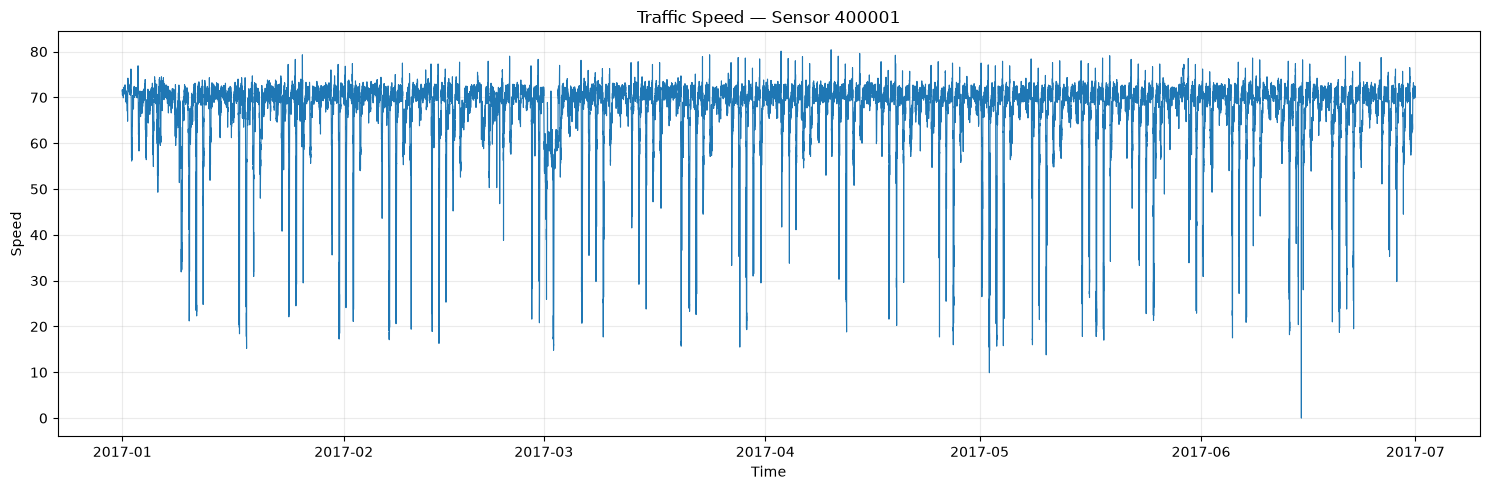

In [6]:
# 6. Traffic pattern visualization
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(series.index, series.values, linewidth=0.8)
ax.set_title(f"Traffic Speed — Sensor {SENSOR_ID}")
ax.set_xlabel("Time")
ax.set_ylabel("Speed")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


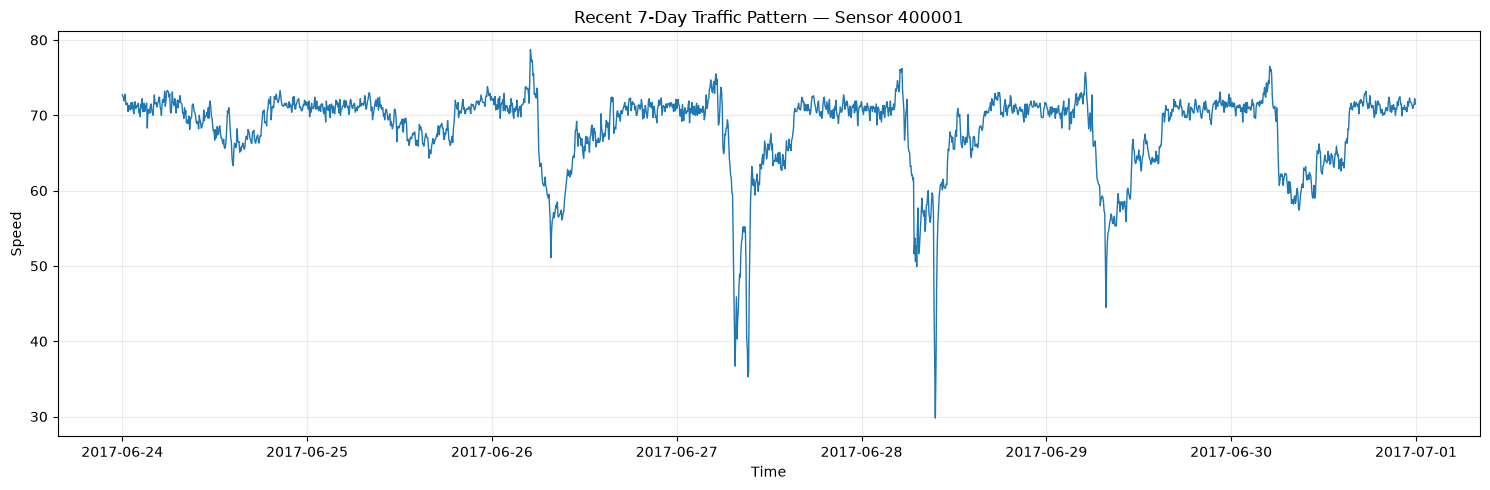

In [7]:
# 7. Recent traffic pattern
recent = series.tail(7 * 24 * 12)  # approximately last 7 days at 5-minute intervals

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(recent.index, recent.values, linewidth=1)
ax.set_title(f"Recent 7-Day Traffic Pattern — Sensor {SENSOR_ID}")
ax.set_xlabel("Time")
ax.set_ylabel("Speed")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [8]:
# 8. Feature engineering
data = pd.DataFrame({"traffic": series})

data["hour"] = data.index.hour
data["minute"] = data.index.minute
data["dayofweek"] = data.index.dayofweek
data["dayofyear"] = data.index.dayofyear
data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

# Cyclic time features
data["hour_sin"] = np.sin(2 * np.pi * (data["hour"] + data["minute"]/60) / 24)
data["hour_cos"] = np.cos(2 * np.pi * (data["hour"] + data["minute"]/60) / 24)
data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

# Lag features: 5 min, 15 min, 30 min, 1 hour, 2 hours, 1 day, 1 week
lags = [1, 3, 6, 12, 24, 288, 2016]
for lag in lags:
    data[f"lag_{lag}"] = data["traffic"].shift(lag)

# Rolling statistics
data["rolling_mean_1h"] = data["traffic"].shift(1).rolling(12).mean()
data["rolling_std_1h"] = data["traffic"].shift(1).rolling(12).std()
data["rolling_mean_3h"] = data["traffic"].shift(1).rolling(36).mean()

data = data.dropna()

print("Feature matrix:", data.shape)
display(data.head())


Feature matrix: (50100, 20)


,traffic,hour,minute,dayofweek,dayofyear,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,lag_1,lag_3,lag_6,lag_12,lag_24,lag_288,lag_2016,rolling_mean_1h,rolling_std_1h,rolling_mean_3h
Unnamed: 0,,,,,,,,,,,,,,,,,,,,
2017-01-08 00:00:00,71.6,0,0,6,8,1,0.000000,1.000000,-0.781831,0.62349,71.1,70.7,70.3,70.6,68.4,71.7,71.4,70.400000,0.502720,69.011111
2017-01-08 00:05:00,71.9,0,5,6,8,1,0.021815,0.999762,-0.781831,0.62349,71.6,70.9,71.1,70.0,68.5,70.6,71.6,70.483333,0.610266,69.133333
2017-01-08 00:10:00,70.4,0,10,6,8,1,0.043619,0.999048,-0.781831,0.62349,71.9,71.1,70.4,69.8,68.8,71.0,71.6,70.641667,0.711539,69.247222
2017-01-08 00:15:00,71.1,0,15,6,8,1,0.065403,0.997859,-0.781831,0.62349,70.4,71.6,70.7,69.9,68.9,71.1,71.1,70.691667,0.666686,69.316667
2017-01-08 00:20:00,70.4,0,20,6,8,1,0.087156,0.996195,-0.781831,0.62349,71.1,71.9,70.9,69.6,69.0,71.0,71.7,70.791667,0.625893,69.422222


## 9. Chronological train/validation/test split

For time-series forecasting, random train/test splitting can leak future information. We therefore preserve chronological order:

- **70% training**
- **15% validation**
- **15% test**

The test set is used only for final evaluation.


In [9]:
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = data.iloc[:train_end]
val = data.iloc[train_end:val_end]
test = data.iloc[val_end:]

feature_cols = [c for c in data.columns if c != "traffic"]

X_train, y_train = train[feature_cols], train["traffic"]
X_val, y_val = val[feature_cols], val["traffic"]
X_test, y_test = test[feature_cols], test["traffic"]

print("Train:", train.index.min(), "→", train.index.max(), len(train))
print("Validation:", val.index.min(), "→", val.index.max(), len(val))
print("Test:", test.index.min(), "→", test.index.max(), len(test))


Train: 2017-01-08 00:00:00 → 2017-05-09 19:25:00 35070
Validation: 2017-05-09 19:30:00 → 2017-06-04 21:40:00 7515
Test: 2017-06-04 21:45:00 → 2017-06-30 23:55:00 7515


In [10]:
# 10. Metrics helper
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []


## 11. Baseline: persistence forecast

The baseline predicts the current traffic value as the next value. This is important because a machine-learning model should demonstrate improvement over a simple forecasting rule.


In [11]:
baseline_pred = X_test["lag_1"].values
results.append(evaluate_model("Persistence baseline", y_test.values, baseline_pred))


Persistence baseline
MAE  : 0.9653
RMSE : 1.9905
R²   : 0.9395


## 12. Random Forest time-series model

Random Forest is used as a strong non-neural baseline using lagged traffic and calendar features.

It does not inherently understand sequence order, so the lag and time features provide the temporal information explicitly.


In [12]:
rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
results.append(evaluate_model("Random Forest", y_test.values, rf_pred))


Random Forest
MAE  : 0.8978
RMSE : 1.8328
R²   : 0.9487


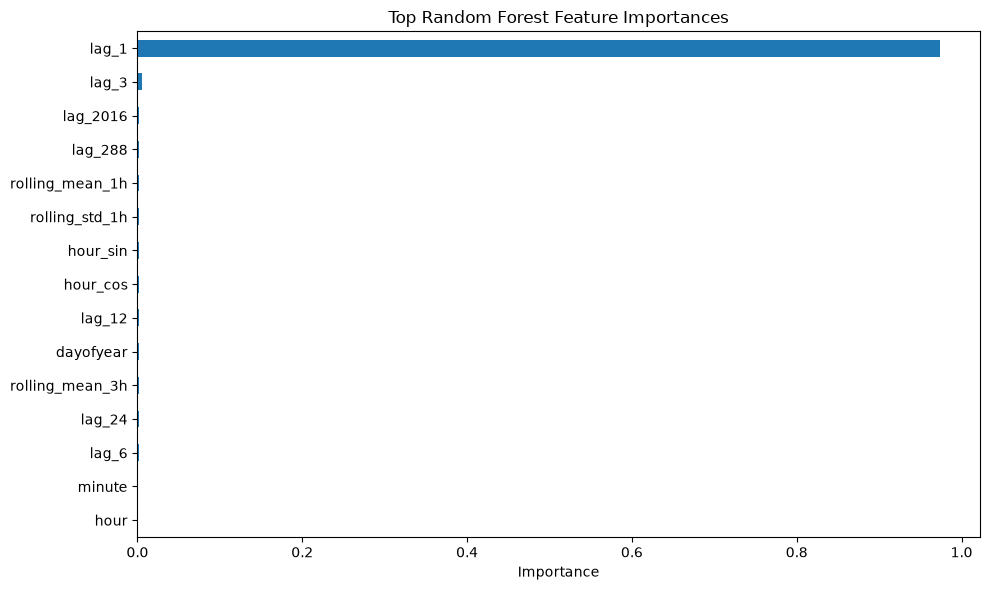

lag_1              0.973711
lag_3              0.005354
lag_2016           0.001971
lag_288            0.001969
rolling_mean_1h    0.001751
rolling_std_1h     0.001747
hour_sin           0.001719
hour_cos           0.001630
lag_12             0.001550
dayofyear          0.001522
rolling_mean_3h    0.001487
lag_24             0.001482
lag_6              0.001422
minute             0.001176
hour               0.000555
dtype: float64

In [13]:
# 13. Feature importance
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance.head(15))


## 14. LSTM sequence model

The LSTM uses a rolling history window to learn temporal dependencies directly.

For a practical notebook, the sequence length is 288 points = 24 hours at 5-minute intervals.


In [14]:
# TensorFlow/Keras LSTM
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

LOOKBACK = 288  # 24 hours
target = series.values.astype("float32")

# Scale using training data only
split_train = int(len(target) * 0.70)
split_val = int(len(target) * 0.85)

scaler = StandardScaler()
scaler.fit(target[:split_train].reshape(-1, 1))
scaled = scaler.transform(target.reshape(-1, 1)).flatten()

def make_sequences(values, start, end, lookback):
    X, y = [], []
    for i in range(max(start, lookback), end):
        X.append(values[i-lookback:i])
        y.append(values[i])
    return np.array(X)[..., None], np.array(y)

X_lstm_train, y_lstm_train = make_sequences(scaled, 0, split_train, LOOKBACK)
X_lstm_val, y_lstm_val = make_sequences(scaled, split_train, split_val, LOOKBACK)
X_lstm_test, y_lstm_test = make_sequences(scaled, split_val, len(scaled), LOOKBACK)

print(X_lstm_train.shape, X_lstm_val.shape, X_lstm_test.shape)


TensorFlow: 2.21.0
(36193, 288, 1) (7817, 288, 1) (7818, 288, 1)


In [15]:
# 15. Build and train LSTM
lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 85s 288ms/step - loss: 0.1470 - mae: 0.1993 - val_loss: 0.0610 - val_mae: 0.1474
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 83s 293ms/step - loss: 0.0560 - mae: 0.1416 - val_loss: 0.0424 - val_mae: 0.1264
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 87s 308ms/step - loss: 0.0452 - mae: 0.1294 - val_loss: 0.0384 - val_mae: 0.1222
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 85s 300ms/step - loss: 0.0431 - mae: 0.1269 - val_loss: 0.0378 - val_mae: 0.1184
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 84s 299ms/step - loss: 0.0406 - mae: 0.1233 - val_loss: 0.0376 - val_mae: 0.1205
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 105s 373ms/step - loss: 0.0404 - mae: 0.1230 - val_loss: 0.0396 - val_mae: 0.1221
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 85s 301ms/step - loss: 0.0402 - mae: 0.1221 - val_loss: 0.0368 - val_mae: 0.1159
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 87s 308ms/step - loss: 0.0387 - mae: 0.1207 - val_loss: 0.0346 - val_mae: 0.1160
Epoch 9/30
283/283 ━━━━━━━━━━━━

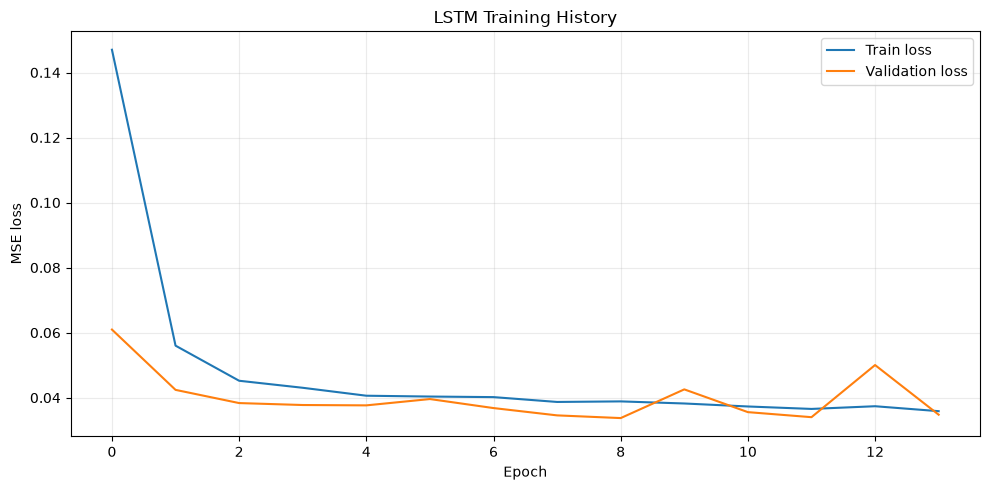

In [16]:
# 16. LSTM training curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["loss"], label="Train loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_title("LSTM Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [17]:
# 17. LSTM test evaluation
lstm_scaled_pred = lstm.predict(X_lstm_test, verbose=0).flatten()

lstm_pred = scaler.inverse_transform(
    lstm_scaled_pred.reshape(-1, 1)
).flatten()

lstm_actual = scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

results.append(evaluate_model("LSTM", lstm_actual, lstm_pred))


LSTM
MAE  : 0.8802
RMSE : 1.7203
R²   : 0.9534


,Model,MAE,RMSE,R2
2,LSTM,0.880227,1.720279,0.953362
1,Random Forest,0.897775,1.832757,0.948739
0,Persistence baseline,0.965323,1.990470,0.939538


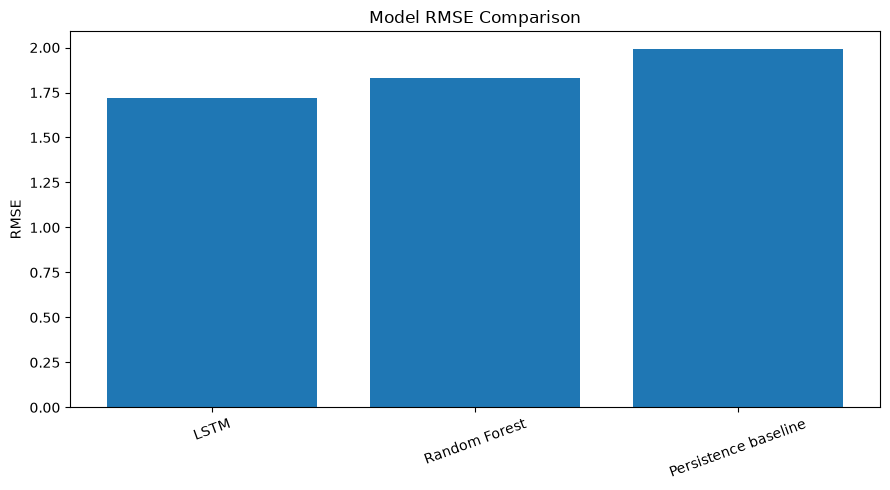

In [18]:
# 18. Compare models
results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


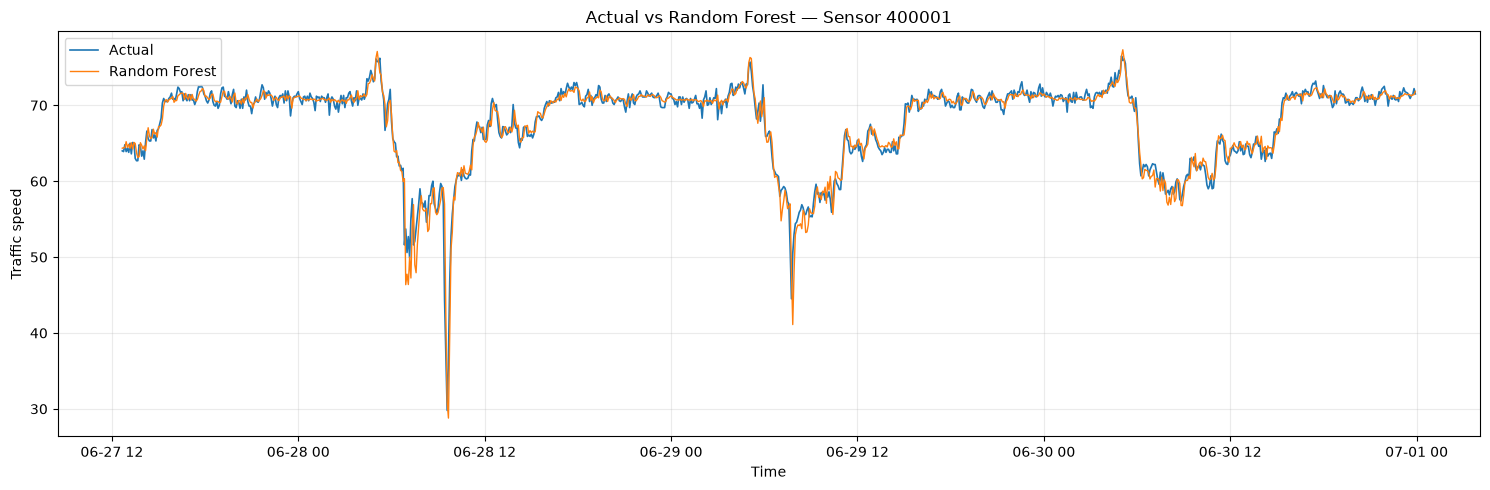

In [19]:
# 19. Plot actual vs Random Forest predictions
plot_n = min(1000, len(y_test))

plt.figure(figsize=(15, 5))
plt.plot(y_test.index[-plot_n:], y_test.values[-plot_n:], label="Actual", linewidth=1.2)
plt.plot(y_test.index[-plot_n:], rf_pred[-plot_n:], label="Random Forest", linewidth=1)
plt.title(f"Actual vs Random Forest — Sensor {SENSOR_ID}")
plt.xlabel("Time")
plt.ylabel("Traffic speed")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [20]:
# 20. One-hour recursive LSTM forecast
# Forecasts the next 12 five-minute intervals from the latest available history.

history_values = scaled[-LOOKBACK:].copy()
future_scaled = []

for _ in range(12):
    x = history_values[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    pred = lstm.predict(x, verbose=0)[0, 0]
    future_scaled.append(pred)
    history_values = np.append(history_values, pred)

future_forecast = scaler.inverse_transform(
    np.array(future_scaled).reshape(-1, 1)
).flatten()

future_index = pd.date_range(
    start=series.index[-1] + pd.Timedelta(minutes=5),
    periods=12,
    freq="5min"
)

forecast_df = pd.DataFrame({
    "timestamp": future_index,
    "forecast_speed": future_forecast
})

display(forecast_df)


,timestamp,forecast_speed
0,2017-07-01 00:00:00,71.545944
1,2017-07-01 00:05:00,71.421295
2,2017-07-01 00:10:00,71.340759
3,2017-07-01 00:15:00,71.288704
4,2017-07-01 00:20:00,71.255798
5,2017-07-01 00:25:00,71.233612
6,2017-07-01 00:30:00,71.216148
7,2017-07-01 00:35:00,71.200111
8,2017-07-01 00:40:00,71.184280
9,2017-07-01 00:45:00,71.168663


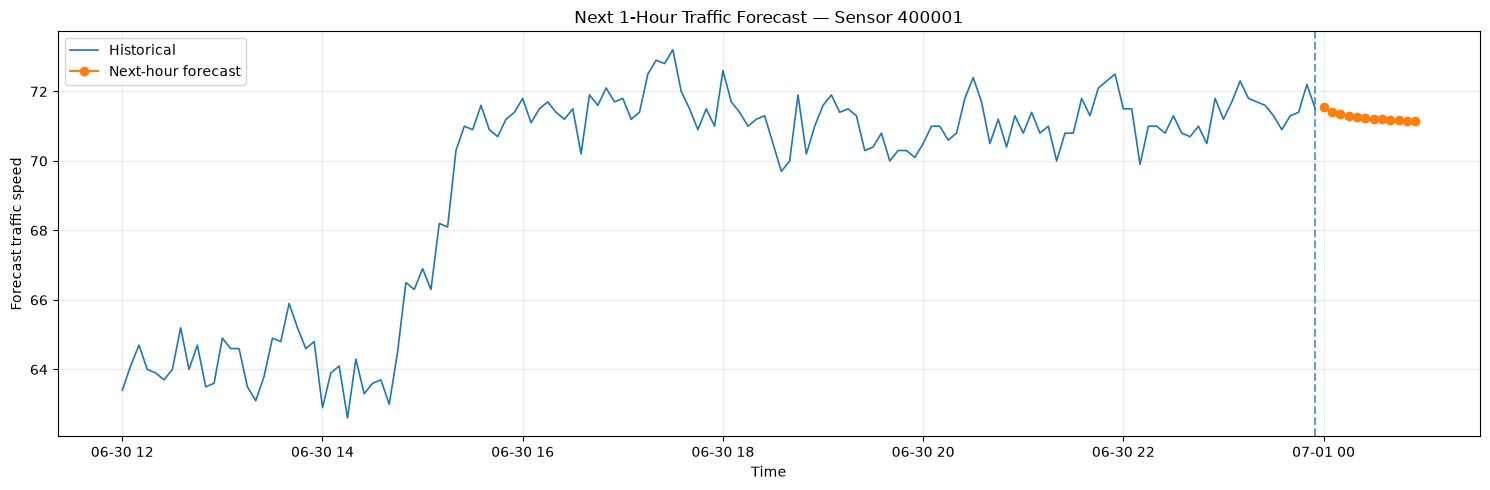

In [21]:
# 21. Visualize the next-hour forecast
history_plot = series.tail(144)  # last 12 hours

plt.figure(figsize=(15, 5))
plt.plot(history_plot.index, history_plot.values, label="Historical", linewidth=1.2)
plt.plot(
    forecast_df["timestamp"],
    forecast_df["forecast_speed"],
    marker="o",
    label="Next-hour forecast"
)
plt.axvline(series.index[-1], linestyle="--", alpha=0.7)
plt.title(f"Next 1-Hour Traffic Forecast — Sensor {SENSOR_ID}")
plt.xlabel("Time")
plt.ylabel("Forecast traffic speed")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 22. Traffic pattern analysis

The following section summarizes hourly and weekday patterns from the selected sensor. These patterns can be useful for identifying recurring congestion periods.


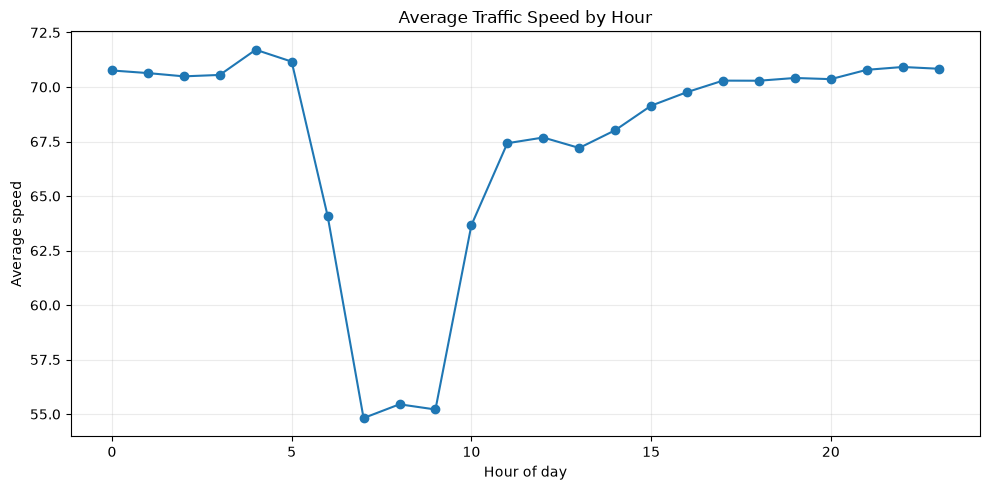

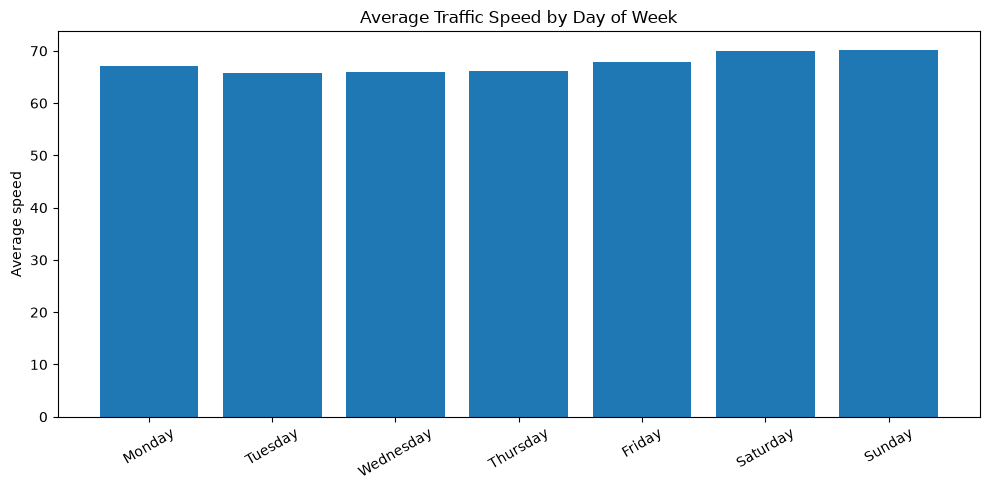

,mean_speed
hour,
0,70.756722
1,70.637477
2,70.487407
3,70.552394
4,71.707136
5,71.163076
6,64.089779
7,54.818508
8,55.450783


,mean_speed
weekday,
Monday,67.113341
Tuesday,65.763395
Wednesday,65.878432
Thursday,66.167455
Friday,67.909215
Saturday,70.018083
Sunday,70.228451


In [22]:
pattern = pd.DataFrame({"traffic": series})
pattern["hour"] = pattern.index.hour
pattern["weekday"] = pattern.index.day_name()

hourly = pattern.groupby("hour")["traffic"].mean()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday = pattern.groupby("weekday")["traffic"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly.index, hourly.values, marker="o")
ax.set_title("Average Traffic Speed by Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average speed")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weekday.index, weekday.values)
ax.set_title("Average Traffic Speed by Day of Week")
ax.set_ylabel("Average speed")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

display(hourly.to_frame("mean_speed"))
display(weekday.to_frame("mean_speed"))


## 23. Conclusions

### What this project demonstrates

1. Traffic data is treated as a chronological time series.
2. Lag and calendar features capture recurring traffic patterns.
3. A persistence baseline establishes a simple benchmark.
4. Random Forest provides a non-neural forecasting model.
5. LSTM learns temporal dependencies from a 24-hour history window.
6. Models are evaluated using MAE, RMSE and R².
7. The final LSTM produces a 1-hour / 12-step traffic forecast.

### Important limitation

PEMS-BAY is a historical benchmark rather than a live traffic feed. For a real-world deployment, replace the download section with a current traffic API or sensor stream, then retrain/recalibrate the forecasting pipeline regularly.

### Possible extensions

- Multi-step direct forecasting instead of recursive LSTM forecasting
- XGBoost/LightGBM comparison
- GRU and Transformer models
- Weather and holiday features
- Multi-sensor forecasting
- Graph Neural Networks using the sensor adjacency matrix
- Prediction intervals / uncertainty forecasting
- Real-time dashboard with Streamlit


## References

- PEMS-BAY public dataset archive: Zenodo, DOI **10.5281/zenodo.4264445**
- Li et al., *Diffusion Convolutional Recurrent Neural Network: Data-Driven Traffic Forecasting*, ICLR 2018.
- Processed PEMS-BAY benchmark documentation: Hugging Face dataset card.

**Reproducibility:** Random Forest uses `random_state=42`; the time-series split is chronological to reduce temporal leakage.
